План

* bpe с щепоткой алгосов

* bbpe

* word2vec с кроссэнтропией

## Про токенизацию

https://docs.google.com/presentation/d/1fQKEFvb_M08N3lPIg-XzFPlVfc3Q2U7_f_IkmXaufv4/edit?usp=sharing

## Word2Vec training

### Подгрузим данные

In [1]:
!wget https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.train.tokens
!wget https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.valid.tokens

--2026-01-31 15:34:58--  https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.train.tokens
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10797148 (10M) [text/plain]
Saving to: ‘wiki.train.tokens’

wiki.train.tokens   100%[===================>]  10,30M  10,1MB/s    in 1,0s    

2026-01-31 15:35:00 (10,1 MB/s) - ‘wiki.train.tokens’ saved [10797148/10797148]

--2026-01-31 15:35:01--  https://raw.githubusercontent.com/iliaschalkidis/ELMo-keras/refs/heads/master/data/datasets/wikitext-2/wiki.valid.tokens
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|

In [2]:
!pip install --break-system-packages nltk seaborn matplotlib gensim jupyter ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 8.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [gensim]2m4/5 [gensim]

[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: pip install --upgrade pip


### Токенизируем "по словам" корпус

У торча есть библиотека torchtext для работе с текстами, но она deprecated (и на багованно ставится), поэтому возьмем `nltk`

In [3]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import WordPunctTokenizer


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 14})

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [4]:
TRAIN_TOKENS = './wiki.train.tokens'
VALID_TOKENS = './wiki.valid.tokens'

SKIPGRAM_N_WORDS = 4
MIN_WORD_FREQUENCY = 20
MAX_SEQUENCE_LENGTH = 256

EMBED_DIM = 256
EMBED_MAX_NORM = 1
BATCH_SIZE = 16
NUM_EPOCHS = 20

In [5]:
tokenizer = WordPunctTokenizer()

In [6]:
with open(TRAIN_TOKENS, 'r') as file:
    lines = file.readlines()


lines[:4], len(lines)

([' \n',
  ' = Valkyria Chronicles III = \n',
  ' \n',
  ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . <unk> the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n'],
 36718)

In [7]:
list(map(tokenizer.tokenize, lines[:4]))

[[],
 ['=', 'Valkyria', 'Chronicles', 'III', '='],
 [],
 ['Senjō',
  'no',
  'Valkyria',
  '3',
  ':',
  '<',
  'unk',
  '>',
  'Chronicles',
  '(',
  'Japanese',
  ':',
  '戦場のヴァルキュリア3',
  ',',
  'lit',
  '.',
  'Valkyria',
  'of',
  'the',
  'Battlefield',
  '3',
  ')',
  ',',
  'commonly',
  'referred',
  'to',
  'as',
  'Valkyria',
  'Chronicles',
  'III',
  'outside',
  'Japan',
  ',',
  'is',
  'a',
  'tactical',
  'role',
  '@-@',
  'playing',
  'video',
  'game',
  'developed',
  'by',
  'Sega',
  'and',
  'Media',
  '.',
  'Vision',
  'for',
  'the',
  'PlayStation',
  'Portable',
  '.',
  'Released',
  'in',
  'January',
  '2011',
  'in',
  'Japan',
  ',',
  'it',
  'is',
  'the',
  'third',
  'game',
  'in',
  'the',
  'Valkyria',
  'series',
  '.',
  '<',
  'unk',
  '>',
  'the',
  'same',
  'fusion',
  'of',
  'tactical',
  'and',
  'real',
  '@-@',
  'time',
  'gameplay',
  'as',
  'its',
  'predecessors',
  ',',
  'the',
  'story',
  'runs',
  'parallel',
  'to',
  'the',

In [8]:
def load_and_preprocess_dataset(path):
    with open(path, 'r') as file:
        lines = file.readlines()

    data = list(filter(
        lambda sent: len(sent) > SKIPGRAM_N_WORDS * 2,
        map(tokenizer.tokenize, lines)
    ))
    return data

In [13]:
train_data = load_and_preprocess_dataset(TRAIN_TOKENS)
valid_data = load_and_preprocess_dataset(VALID_TOKENS)
print(train_data[0])
total_train_tokens = sum(len(sent) for sent in train_data)
total_valid_tokens = sum(len(sent) for sent in valid_data)

print(f'Num sentences: train - {len(train_data)}, valid - {len(valid_data)}')
print(f'Total tokens: train - {total_train_tokens}, valid - {total_valid_tokens}')
print(f'Average tokens in sentence: {total_train_tokens / len(train_data):.2f}')

['Senjō', 'no', 'Valkyria', '3', ':', '<', 'unk', '>', 'Chronicles', '(', 'Japanese', ':', '戦場のヴァルキュリア3', ',', 'lit', '.', 'Valkyria', 'of', 'the', 'Battlefield', '3', ')', ',', 'commonly', 'referred', 'to', 'as', 'Valkyria', 'Chronicles', 'III', 'outside', 'Japan', ',', 'is', 'a', 'tactical', 'role', '@-@', 'playing', 'video', 'game', 'developed', 'by', 'Sega', 'and', 'Media', '.', 'Vision', 'for', 'the', 'PlayStation', 'Portable', '.', 'Released', 'in', 'January', '2011', 'in', 'Japan', ',', 'it', 'is', 'the', 'third', 'game', 'in', 'the', 'Valkyria', 'series', '.', '<', 'unk', '>', 'the', 'same', 'fusion', 'of', 'tactical', 'and', 'real', '@-@', 'time', 'gameplay', 'as', 'its', 'predecessors', ',', 'the', 'story', 'runs', 'parallel', 'to', 'the', 'first', 'game', 'and', 'follows', 'the', '"', 'Nameless', '"', ',', 'a', 'penal', 'military', 'unit', 'serving', 'the', 'nation', 'of', 'Gallia', 'during', 'the', 'Second', 'Europan', 'War', 'who', 'perform', 'secret', 'black', 'operations

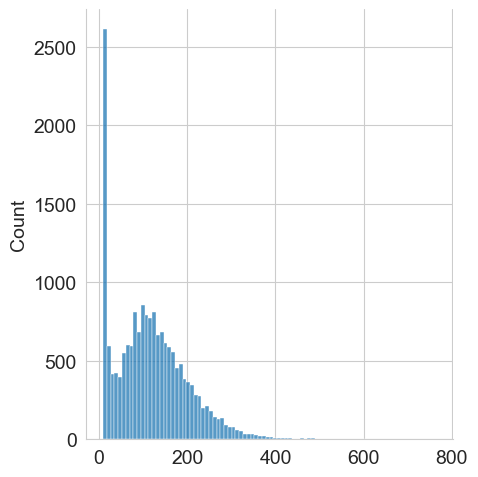

In [10]:
_ = sns.displot([len(sent) for sent in train_data])

In [14]:
train_data[0]

['Senjō',
 'no',
 'Valkyria',
 '3',
 ':',
 '<',
 'unk',
 '>',
 'Chronicles',
 '(',
 'Japanese',
 ':',
 '戦場のヴァルキュリア3',
 ',',
 'lit',
 '.',
 'Valkyria',
 'of',
 'the',
 'Battlefield',
 '3',
 ')',
 ',',
 'commonly',
 'referred',
 'to',
 'as',
 'Valkyria',
 'Chronicles',
 'III',
 'outside',
 'Japan',
 ',',
 'is',
 'a',
 'tactical',
 'role',
 '@-@',
 'playing',
 'video',
 'game',
 'developed',
 'by',
 'Sega',
 'and',
 'Media',
 '.',
 'Vision',
 'for',
 'the',
 'PlayStation',
 'Portable',
 '.',
 'Released',
 'in',
 'January',
 '2011',
 'in',
 'Japan',
 ',',
 'it',
 'is',
 'the',
 'third',
 'game',
 'in',
 'the',
 'Valkyria',
 'series',
 '.',
 '<',
 'unk',
 '>',
 'the',
 'same',
 'fusion',
 'of',
 'tactical',
 'and',
 'real',
 '@-@',
 'time',
 'gameplay',
 'as',
 'its',
 'predecessors',
 ',',
 'the',
 'story',
 'runs',
 'parallel',
 'to',
 'the',
 'first',
 'game',
 'and',
 'follows',
 'the',
 '"',
 'Nameless',
 '"',
 ',',
 'a',
 'penal',
 'military',
 'unit',
 'serving',
 'the',
 'nation',
 

In [14]:
from itertools import chain
from typing import Iterable, Union

In [15]:
from collections import Counter
from operator import itemgetter

In [16]:
a = [1, 2, 3]
a[0:0] = [5]
a

[5, 1, 2, 3]

Cоздадим словарь на основе полученной токенизации, оставив только те токены, которые встречаются чаще MIN_WORD_FREQUENCY, остальные заменим на UNK

In [ ]:
class VocabPseudoVectorized:
    def __init__(self, train_data: Iterable[str],
                 unk_label: str = "<UNK>",
                 unk_cutoff: int = MIN_WORD_FREQUENCY):
        raw_counts = Counter(train_data)
        
        for token, frequency in tuple(raw_counts.items()):
            if frequency >= unk_cutoff:
                continue
            raw_counts.pop(token)
        remaining_tokens = list(raw_counts.keys())
        # add UNK token:
        remaining_tokens[0:0] = [unk_label]
#         Это конвенция в NLP:
# Индекс 0 почти всегда зарезервирован для специальных токенов
# <UNK>, <PAD>, <SOS>, <EOS> часто имеют индексы 0, 1, 2, 3

        self._token2idx = {
            token: id_ for id_, token in enumerate(remaining_tokens)
        }
        self._idx2token = {
            id_: token for id_, token in enumerate(remaining_tokens)
        }

    def _fetch_index(self, item: str):
        return self._token2idx.get(item, 0)  # <--- UNK token

    def __getitem__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        if isinstance(item, Iterable) and not isinstance(item, str):
            return list(map(self.__getitem__, item))
    
        return self._fetch_index(item)

    def __call__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        return self[item]

    def __len__(self, ):
        return len(self._token2idx)

    def __contains__(self, item):
        return item in self._token2idx

    def lookup(self, item: Union[str, Iterable[str]]):
        result = []
        if isinstance(item, str):
            return self[item]
        for x in item:
            result.append(self.lookup(x))
        return result

    def get_itos(self, items: Iterable[str]):
        if isinstance(items, torch.Tensor):
            items = items.detach().cpu().tolist()
        return [self._idx2token[i] for i in items]

In [ ]:
vocab = VocabPseudoVectorized(chain(*train_data))
VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

Vocab size: 8716


In [20]:
train_data[102]

['National',
 'Mission',
 ';',
 'Society',
 'for',
 'the',
 'Preservation',
 'of',
 'Christian',
 'Knowledge',
 ',',
 '1916']

In [21]:
train_data[123]

['Flower', 'Fairies', 'of', 'the', 'Trees', ';', 'Blackie', ',', '1940']

In [22]:
vocab[train_data[123]]

[864, 1538, 14, 15, 1878, 373, 1655, 11, 1686]

In [22]:
vocab.get_itos(vocab[train_data[123]]) == train_data[123]  # Правдиво только если не встретится неизвестный токен

True

In [23]:
vocab(['skibididopdopdopyesyesyes'])

[0]

In [24]:
vocab.lookup(["ASDASD", "asdaa", ["cat", "dog"]])

[0, 0, [4016, 3902]]

In [26]:
vocab["Mission"]

1867

In [27]:
vocab["<UNK>"]

0

In [28]:
vocab("cat")

4016

In [29]:
vocab("13123123123")

0

Положим семплы в батче так, чтобы было удобно учить модель предсказывать вероятности $p(w_i|w_j)$, потому что хотим учить skip-gram версию word2vec. $w_j$ - слово стоящее по центру, $w_i$ - слова из SKIPGRAM_N_WORDS окрестности.

In [25]:
def collate_fn(batch):
    """
    # T_1, T_2, T_3, T_4
    Collate_fn for Skip-Gram model to be used with Dataloader.
    `batch` is expected to be list of text paragrahs.

    Context is represented as N=SKIPGRAM_N_WORDS past words 
    and N=SKIPGRAM_N_WORDS future words.

    Long paragraphs will be truncated to contain
    no more that MAX_SEQUENCE_LENGTH tokens.

    Each element in `batch_input` is a middle word.
    Each element in `batch_output` is a context word.
    """
    batch_input, batch_output = [], []
    for text in batch:
        text_tokens_ids = vocab(text) # получаем индексы от токенов (слов)

        if MAX_SEQUENCE_LENGTH:
            text_tokens_ids = text_tokens_ids[:MAX_SEQUENCE_LENGTH]

        for idx in range(len(text_tokens_ids) - SKIPGRAM_N_WORDS * 2): # проходимся скользящим окном 
            token_id_sequence = text_tokens_ids[idx : (idx + SKIPGRAM_N_WORDS * 2 + 1)] # окно 
            input_ = token_id_sequence.pop(SKIPGRAM_N_WORDS) # центральное слово 
            outputs = token_id_sequence # контекст

            batch_input += [input_] * len(outputs) # center_world center_world center_world... (indexses)
            batch_output += outputs # context1, contex2 (indexcis)

    batch_input = torch.tensor(batch_input, dtype=torch.long)
    batch_output = torch.tensor(batch_output, dtype=torch.long)
    return batch_input, batch_output

In [ ]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, num_workers=0,
                          pin_memory=False, collate_fn=collate_fn, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, num_workers=0,
                          pin_memory=False, collate_fn=collate_fn)

### Код для обучения и сам класс модели

In [ ]:
from IPython.display import clear_output
from tqdm.notebook import tqdm


def plot_losses(train_losses, valid_losses):
    clear_output()
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='train', color='deepskyblue', linewidth=2)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='valid', color='springgreen', linewidth=2)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.show()

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss, num_batches = 0.0, 1
    model.train()
    for inputs, outputs in tqdm(train_loader, desc=tqdm_desc):
        inputs = inputs.to(device)
        outputs = outputs.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, outputs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        num_batches += 1

    train_loss /= num_batches
    return train_loss


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc):
    valid_loss, num_batches = 0.0, 0
    model.eval()
    for inputs, outputs in tqdm(valid_loader, desc=tqdm_desc):
        inputs = inputs.to(device)
        outputs = outputs.to(device)

        logits = model(inputs)
        loss = criterion(logits, outputs)

        valid_loss += loss.item()
        num_batches += 1

    valid_loss /= num_batches
    return valid_loss


def train(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs):
    train_losses, valid_losses = [], []

    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        valid_loss = validation_epoch(
            model, criterion, valid_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        valid_losses += [valid_loss]
        plot_losses(train_losses, valid_losses)

In [29]:
tokens = torch.tensor([1, 2, 2, 3, 2, 4, 0, 0])
tokens

tensor([1, 2, 2, 3, 2, 4, 0, 0])

In [30]:
import torch.nn as nn


emb = nn.Embedding(6, 16)

emb.weight

Parameter containing:
tensor([[ 1.8195,  0.3283,  0.2707, -0.5232,  0.3206,  0.6607,  0.0828,  0.0474,
         -1.2439,  1.6110,  0.4002,  0.5337, -0.2278,  0.9209, -0.3631,  0.8492],
        [-0.2013,  0.6836,  1.2103, -0.8861, -0.3732,  2.0845, -0.6618, -0.5876,
         -0.5705,  0.9428, -0.2807,  0.4922, -0.8700, -1.4300,  0.0184,  0.4945],
        [-0.8728,  0.1144, -0.6616,  0.1214, -0.5303, -0.1371,  0.6586,  0.3207,
          0.2515, -0.7772,  0.4610,  0.6609,  0.5645, -1.9049, -0.4695,  0.1476],
        [-0.6451, -1.6384,  1.2489, -2.6908,  0.2063,  1.5960, -1.9050,  1.2182,
          0.2035, -0.6101, -0.2533, -0.0818, -0.3043,  0.1209, -1.1316, -1.4320],
        [ 1.1209, -1.6241, -1.6821,  1.1200,  0.6922, -0.7635,  0.4883,  2.6673,
         -0.9841,  0.2061,  0.2341,  0.4913,  2.0586,  1.4001,  1.4899,  0.4400],
        [-0.3069,  0.0649,  2.0297, -0.0883, -0.0542,  0.1442,  0.0168, -0.5167,
         -0.7796,  0.7343, -0.7091,  0.5415, -0.7035,  0.1789,  1.0532, -0.6696]],

In [ ]:
embeds = emb(tokens)
embeds

tensor([[-0.8060, -1.5609,  0.2763,  0.7724,  0.8353,  0.9750,  0.5713,  0.7725,
          0.9344,  0.5771, -0.3303, -1.3551,  0.8922,  0.2476,  0.0780,  1.1384],
        [ 0.4939, -0.1710, -1.2975,  0.5437, -0.7356, -2.2594,  1.0058,  0.2495,
         -0.7700,  0.6611, -0.5834,  0.4472,  0.5325,  1.1173,  0.9859,  2.1781],
        [ 0.4939, -0.1710, -1.2975,  0.5437, -0.7356, -2.2594,  1.0058,  0.2495,
         -0.7700,  0.6611, -0.5834,  0.4472,  0.5325,  1.1173,  0.9859,  2.1781],
        [ 0.9525, -1.2299,  0.5657, -0.1322,  0.8133, -0.1153, -0.5146, -0.1873,
          0.0430,  1.6887, -0.2978,  0.5337, -0.3710,  2.2734, -1.0866, -0.4371],
        [ 0.4939, -0.1710, -1.2975,  0.5437, -0.7356, -2.2594,  1.0058,  0.2495,
         -0.7700,  0.6611, -0.5834,  0.4472,  0.5325,  1.1173,  0.9859,  2.1781],
        [ 0.0107, -0.5524,  0.8326,  1.4477,  0.7063,  1.6254,  0.1250,  0.9204,
          1.4084, -1.5701, -1.5933,  0.0201,  1.2890,  0.0343,  1.5320, -0.8192],
        [-0.3893,  0.4

In [ ]:
class Word2VecModel(nn.Module):
    def __init__(self, embed_dim, embed_max_norm, vocab_size):
        super().__init__()
         # ЭТО МАТРИЦА U — входные эмбеддинги (центральное слово)
        self.embeds = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim,
                                   max_norm=embed_max_norm)

        # ЭТО МАТРИЦА V — выходные эмбеддинги (контекстное слово)   
        self.decoder = nn.Linear(embed_dim, vocab_size)
    
    def forward(self, tokens):
        embeds = self.embeds(tokens)
        logits = self.decoder(embeds)
        return logits

In [ ]:
NUM_EPOCHS = 10

model = Word2VecModel(embed_dim=EMBED_DIM, embed_max_norm=EMBED_MAX_NORM,
                      vocab_size=VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

In [ ]:
train(model, optimizer, scheduler, criterion, train_loader, valid_loader, NUM_EPOCHS)

Training 1/10:   0%|          | 0/1141 [00:00<?, ?it/s]

/Users/amirhamidullin/PycharmProjects/DL/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=94, pipe_handle=110)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/opt/homebrew/Cellar/python@3.13/3.13.5/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'collate_fn' on <module '__main__' (<class '_frozen_imp

RuntimeError: DataLoader worker (pid(s) 58321, 58322, 58323, 58324) exited unexpectedly

### Посмотрим что получилось

In [75]:
embed_matrix = model.embeds.weight.detach()
embed_norms = (embed_matrix ** 2).sum(1).sqrt()

In [76]:
import re


def get_similarities(embed_vector):
    similarities = embed_matrix @ embed_vector / embed_norms / torch.norm(embed_vector)
    top_indices = similarities.argsort(descending=True)
    return similarities, top_indices


def get_similar(query, num_similar=5):
    print(f'Processing query \"{query}\"')
    split_query = re.split('([^a-zA-Z0-9])', query)
    index = vocab[split_query[0]]
    embed_vector = torch.clone(embed_matrix[index])
    if index > 0:
        print(f'Found word \"{split_query[0]}\" in vocab')
    else:
        print(f'Word \"{split_query[0]}\" not in vocab, using <unk>')

    for i in range(2, len(split_query), 2):
        index = vocab[split_query[i]]
        if index > 0:
            print(f'Found word \"{split_query[i]}\" in vocab, ', end='')
        else:
            print(f'Word \"{split_query[i]}\" not in vocab, using <unk>, ', end='')
        print(f'operation \"{split_query[i - 1]}\"')

        if split_query[i - 1] == '+':
            embed_vector += embed_matrix[index]
        elif split_query[i - 1] == '-':
            embed_vector -= embed_matrix[index]
        else:
            raise ValueError('Unknown operation')

    similarities, top_indices = get_similarities(embed_vector)

    itos = vocab.get_itos(top_indices)
    # print('Top similar:')
    # print(itos)
    for top_index in range(num_similar):
        print(f'    {itos[top_index]}: sim = {similarities[top_index]:.4f}')

In [77]:
get_similar('woman')

Processing query "woman"
Found word "woman" in vocab
    woman: sim = 0.4414
    man: sim = 0.4592
    girl: sim = 0.2598
    child: sim = 0.1986
    boy: sim = 0.2129


In [78]:
get_similar('kick')

Processing query "kick"
Found word "kick" in vocab
    kick: sim = 0.3250
    touchdown: sim = 0.2411
    ECU: sim = 0.2829
    Tech: sim = 0.6109
    penalty: sim = 0.1905


In [79]:
get_similar('help')

Processing query "help"
Found word "help" in vocab
    help: sim = 0.3972
    try: sim = 0.4401
    keep: sim = 0.2982
    accept: sim = 0.1846
    escape: sim = 0.1702


In [80]:
v = get_similar('king-man', num_similar=10)

Processing query "king-man"
Found word "king" in vocab
Found word "man" in vocab, operation "-"
    Clair: sim = 0.0538
    Federal: sim = -0.1243
    Board: sim = 0.2143
    Emperor: sim = -0.1359
    Defense: sim = 0.0219
    Forces: sim = 0.0853
    Bureau: sim = 0.0626
    Aviation: sim = 0.0377
    Education: sim = 0.1927
    Office: sim = 0.0188


In [81]:
v = get_similar('king-man+woman', num_similar=10)

Processing query "king-man+woman"
Found word "king" in vocab
Found word "man" in vocab, operation "-"
Found word "woman" in vocab, operation "+"
    king: sim = 0.4393
    Catherine: sim = 0.3109
    reincarnation: sim = 0.4067
    Trujillo: sim = 0.0678
    saint: sim = 0.2086
    Wilde: sim = 0.4797
    Keats: sim = 0.4495
    Lord: sim = 0.4069
    poem: sim = 0.3896
    Mariana: sim = 0.1773


In [82]:
get_similar('king')

Processing query "king"
Found word "king" in vocab
    king: sim = 0.5091
    Odaenathus: sim = 0.3563
    King: sim = 0.4222
    Lord: sim = 0.1046
    reign: sim = 0.2626
